<a href="https://colab.research.google.com/github/jvgarmatz/ia-ciberseguranca/blob/main/AV1_detector_malware.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AV1 — Experimento com o detector de malware

**Notebook-base:** Aula 5 — Modelagem de um detector de malware

## Das features estáticas ao modelo pronto para o Splunk

Nesta aula vamos construir um detector de malware usando **features já extraídas de executáveis Windows**. Não vamos baixar nem executar malware.

O objetivo não é obter o maior número possível, mas entender o ciclo completo:

1. carregar uma base real e aberta;
2. escolher features com significado para segurança;
3. separar treino, validação e teste sem usar o teste para ajustar decisões;
4. treinar um baseline e um Random Forest;
5. escolher o limiar pelo custo dos erros;
6. investigar quais sinais o modelo usou;
7. exportar um CSV compatível com o laboratório no Splunk.

## Base utilizada

Usaremos **Malware Static and Dynamic Features VxHeaven and VirusTotal**, disponibilizada no UCI Machine Learning Repository.

- 595 arquivos benignos coletados em diretórios *Program Files* do Windows 7 e 8;
- 2.698 amostras de malware do VxHeaven;
- 2.955 amostras fornecidas pelo VirusTotal em 2018;
- aproximadamente 1.087 features estáticas e dinâmicas;
- licença **CC BY 4.0**;
- DOI: https://doi.org/10.24432/C58K6H

> **Limitação importante:** benignos e maliciosos vieram de fontes diferentes. O modelo pode aprender características da coleta — e não apenas de malware. Vamos tratar isso como parte da análise.

## Segurança do laboratório

O arquivo baixado contém apenas tabelas CSV de features. Não há executáveis no notebook.

- Não baixem amostras binárias de malware.
- Não tentem reproduzir as features executando arquivos desconhecidos.
- Para estudos com binários, seria necessário um laboratório isolado, autorização e procedimentos específicos.
- No Splunk, carregaremos somente vetores numéricos.

In [1]:
# Reprodutibilidade: versão com a qual os resultados da AV1 foram conferidos.
import importlib.metadata
import subprocess
import sys

try:
    versao_instalada = importlib.metadata.version('scikit-learn')
except importlib.metadata.PackageNotFoundError:
    versao_instalada = None

if versao_instalada != '1.6.1':
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '--quiet', 'scikit-learn==1.6.1'
    ])

import sklearn
if sklearn.__version__ != '1.6.1':
    raise RuntimeError(
        'Reinicie a sessão do Colab e execute novamente desde a primeira célula '
        'para carregar o scikit-learn 1.6.1.'
    )

# Bibliotecas — o Colab normalmente já possui todas elas
import io, os, zipfile, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid')

## 1. Baixar a base real

O download vem diretamente do UCI. São três CSVs e nenhum arquivo executável.

In [2]:
URL = 'https://archive.ics.uci.edu/static/public/541/malware+static+and+dynamic+features+vxheaven+and+virus+total.zip'
PASTA = Path('/content/uci_malware_541')
ZIP = Path('/content/uci_malware_541.zip')

PASTA.mkdir(parents=True, exist_ok=True)
if not ZIP.exists():
    print('Baixando a base do UCI...')
    urllib.request.urlretrieve(URL, ZIP)

with zipfile.ZipFile(ZIP) as z:
    z.extractall(PASTA)

arquivos = sorted(PASTA.glob('*.csv'))
print('Arquivos encontrados:')
for arq in arquivos:
    print(' -', arq.name, f'({arq.stat().st_size/1e6:.1f} MB)')

Baixando a base do UCI...
Arquivos encontrados:
 - staDynBenignLab.csv (1.5 MB)
 - staDynVt2955Lab.csv (7.6 MB)
 - staDynVxHeaven2698Lab.csv (6.6 MB)


## 2. Carregar e alinhar os três conjuntos

Os CSVs não têm exatamente as mesmas colunas. Vamos conservar apenas as features presentes em todos eles e registrar a origem de cada linha para auditoria.

In [3]:
partes = [(pd.read_csv(arq), arq.stem) for arq in arquivos]

colunas_comuns = sorted(set.intersection(*[set(p.columns) for p, _ in partes]))
df = pd.concat(
    [p[colunas_comuns].copy().assign(source_dataset=nome) for p, nome in partes],
    ignore_index=True
)

# Identificador interno — não será usado como feature
df = df.assign(sample_id=np.arange(len(df)))
df['label'] = pd.to_numeric(df['label'], errors='raise').astype(int)

print('Dimensões:', df.shape)
print('Colunas comuns:', len(colunas_comuns))
print(df.groupby(['source_dataset', 'label']).size())

Dimensões: (6248, 1087)
Colunas comuns: 1085
source_dataset         label
staDynBenignLab        0         595
staDynVt2955Lab        1        2955
staDynVxHeaven2698Lab  1        2698
dtype: int64


### O primeiro alerta de qualidade

Observe a tabela acima: a origem do arquivo praticamente determina o rótulo. Isso significa que **source_dataset, filename, hash, caminho e índice jamais devem entrar no modelo**.

Mesmo removendo esses campos, outras features podem carregar marcas indiretas da origem. Um bom resultado neste dataset deve ser interpretado como demonstração didática, não como garantia de desempenho em produção.

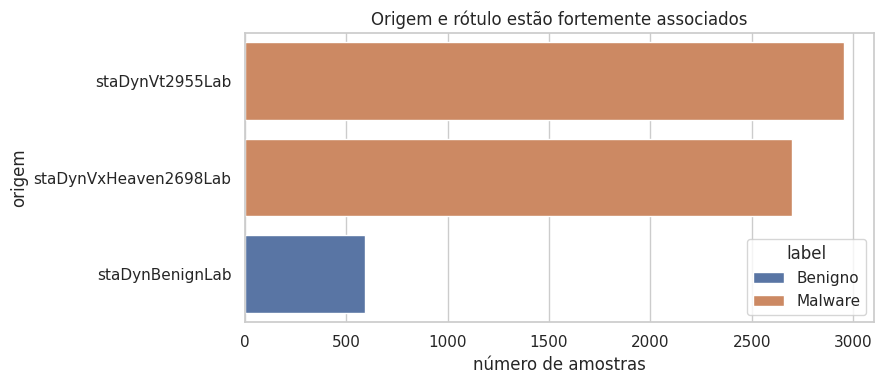

Proporção de malware: 90.5%


In [4]:
plt.figure(figsize=(9, 4))
ordem = df['source_dataset'].value_counts().index
sns.countplot(data=df, y='source_dataset', hue='label', order=ordem)
plt.title('Origem e rótulo estão fortemente associados')
plt.xlabel('número de amostras')
plt.ylabel('origem')
plt.legend(title='label', labels=['Benigno', 'Malware'])
plt.tight_layout()
plt.show()

print('Proporção de malware:', f"{df['label'].mean():.1%}")

## 3. Escolher features com significado

Em vez de entregar mais de mil colunas ao modelo, começaremos com um conjunto pequeno e auditável.

### Famílias escolhidas

- **Estrutura PE:** tamanho, número de seções, entry point e alinhamentos.
- **Entropia e seções:** entropia e tamanho de regiões conhecidas.
- **Imports/capacidades:** presença de APIs ligadas a memória, processos, rede e registro.

Uma API isolada não prova que um arquivo é malicioso. O modelo deve combinar sinais.

In [5]:
features_estrutura = [
    'filesize', 'number_of_sections', 'size_code', 'size_init_data',
    'size_uninit_data', 'size_of_headers', 'size_of_optional_header',
    'AddressOfEntryPoint', 'image_base', 'section_alignment', 'file_alignment'
]

features_entropia = [
    'sec_entropy_data', 'sec_entropy_rdata', 'sec_entropy_reloc',
    'sec_entropy_text', 'sec_entropy_rsrc',
    'sec_rawsize_data', 'sec_rawsize_text'
]

features_imports = [
    'imported_dll_freq', 'number_of_import_symbols',
    'VirtualAlloc', 'VirtualProtect', 'WriteProcessMemory',
    'CreateRemoteThread', 'OpenProcess', 'RegSetValueExA',
    'InternetOpenA', 'URLDownloadToFileA'
]

features = features_estrutura + features_entropia + features_imports
ausentes = [c for c in features if c not in df.columns]
assert not ausentes, f'Features ausentes: {ausentes}'

X = df[features].apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan).fillna(0)
y = df['label']

print(f'{len(features)} features selecionadas de {len(colunas_comuns)} colunas comuns.')
X.head()

28 features selecionadas de 1085 colunas comuns.


,filesize,number_of_sections,size_code,size_init_data,size_uninit_data,size_of_headers,size_of_optional_header,AddressOfEntryPoint,image_base,section_alignment,...,imported_dll_freq,number_of_import_symbols,VirtualAlloc,VirtualProtect,WriteProcessMemory,CreateRemoteThread,OpenProcess,RegSetValueExA,InternetOpenA,URLDownloadToFileA
0,57434,0,10752,10240,0,1024,224,12810,4194304.0,4096,...,0,0,0,0,0,0,0,0,0,0
1,44420,0,8192,8192,0,1024,224,10505,4194304.0,4096,...,0,0,0,0,0,0,0,0,0,0
2,20706,0,3072,8704,0,1024,224,5442,16777216.0,4096,...,0,0,0,0,0,0,0,0,0,0
3,69110,0,19456,10752,0,1024,224,19525,16777216.0,4096,...,0,0,0,0,0,0,0,0,0,0
4,39574,0,8192,7168,0,1024,224,9788,4194304.0,4096,...,0,0,0,0,0,0,0,0,0,0


## 4. Exploração orientada por hipóteses

Vamos criar uma feature agregada apenas para visualização: a média das entropias das seções conhecidas. Ela não substitui as entropias individuais no modelo.

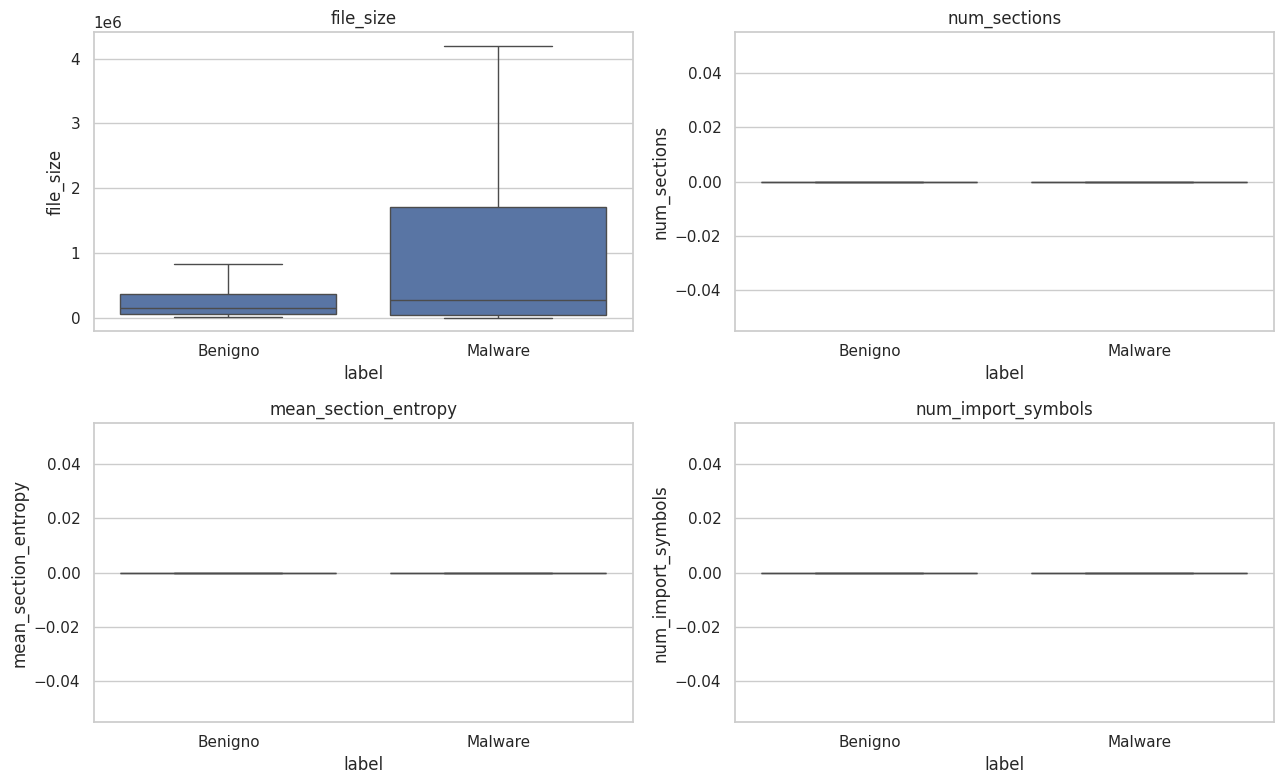

In [6]:
cols_entropia = [c for c in features_entropia if c.startswith('sec_entropy_')]
eda = pd.DataFrame({
    'label': y.map({0: 'Benigno', 1: 'Malware'}),
    'file_size': X['filesize'],
    'num_sections': X['number_of_sections'],
    'mean_section_entropy': X[cols_entropia].mean(axis=1),
    'num_import_symbols': X['number_of_import_symbols']
})

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, coluna in zip(axes.ravel(), eda.columns[1:]):
    sns.boxplot(data=eda, x='label', y=coluna, ax=ax, showfliers=False)
    ax.set_title(coluna)
plt.tight_layout()
plt.show()

### Discussão rápida

- Quais features parecem separar as classes?
- Essa diferença pode ser causada pela forma de coleta?
- Qual delas seria fácil para um atacante manipular?
- Ausência de um import significa ausência daquela capacidade?

## 5. Separar treino, validação e teste

O teste será usado **uma única vez**, depois que o modelo e o limiar estiverem definidos.

- treino: 60%;
- validação: 20%;
- teste: 20%.

Usamos estratificação porque a classe malware é majoritária.

In [7]:
X_treino_val, X_teste, y_treino_val, y_teste = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_SEED
)
X_treino, X_valid, y_treino, y_valid = train_test_split(
    X_treino_val, y_treino_val, test_size=0.25,
    stratify=y_treino_val, random_state=RANDOM_SEED
)

print('Treino   :', X_treino.shape, 'malware:', f'{y_treino.mean():.1%}')
print('Validação:', X_valid.shape,  'malware:', f'{y_valid.mean():.1%}')
print('Teste    :', X_teste.shape,  'malware:', f'{y_teste.mean():.1%}')

Treino   : (3748, 28) malware: 90.5%
Validação: (1250, 28) malware: 90.5%
Teste    : (1250, 28) malware: 90.5%


## 6. Baseline: prever sempre a classe majoritária

Como malware é majoritário, um modelo que sempre responde “malware” pode ter acurácia alta. O baseline revela quanto o modelo precisa superar.

In [8]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_treino, y_treino)
pred_dummy = dummy.predict(X_valid)

print(classification_report(y_valid, pred_dummy, target_names=['Benigno', 'Malware'], zero_division=0))
print('O baseline detecta malware, mas bloqueia todos os benignos.')

              precision    recall  f1-score   support

     Benigno       0.00      0.00      0.00       119
     Malware       0.90      1.00      0.95      1131

    accuracy                           0.90      1250
   macro avg       0.45      0.50      0.48      1250
weighted avg       0.82      0.90      0.86      1250

O baseline detecta malware, mas bloqueia todos os benignos.


## AV1 — Plano do experimento - Até a seção 10!

O objetivo é comparar o detector original com duas alterações, mantendo a mesma base, as mesmas 28 features, a divisão de treino/validação/teste e a semente aleatória (`RANDOM_SEED = 42`). As decisões são tomadas na validação; o teste é reservado para a avaliação final.

1. **Parâmetro do modelo:** aumentar `min_samples_leaf` de **2 para 5** no Random Forest, mantendo 250 árvores. A hipótese é que folhas apoiadas em mais amostras produzam regras menos específicas. Após treinar cada modelo, aplicamos a mesma regra original de seleção do limiar na validação. Assim, o limiar recalculado passa de **0,46 para 0,33**.
2. **Limiar de alerta:** no mesmo modelo com folha mínima 5, alterar diretamente o limiar de **0,33 para 0,21**. Um limiar menor faz o detector classificar mais arquivos como malware. A hipótese é reduzir falsos negativos, aceitando mais falsos positivos.

Precisão, recall e F1 são **métricas calculadas depois das previsões**. Não são valores modificados pelo experimento. A tabela registra três versões: original, folha mínima 5 com limiar recalculado e folha mínima 5 com limiar reduzido.

**Observação sobre a comparação:** original versus folha 5 reflete a mudança do modelo e a recalibração do limiar; não permite atribuir toda a diferença somente ao tamanho da folha. Nas duas versões com folha 5, apenas o limiar muda, permitindo observar seu efeito no mesmo modelo.

**Reprodutibilidade:** a primeira célula de código prepara o `scikit-learn 1.6.1`, versão com a qual os resultados registrados foram reproduzidos. A base, as features e a semente permanecem iguais.


## 7. Treinar o Random Forest

Usamos pesos balanceados para evitar que a classe majoritária domine as árvores. O foco ainda não é otimizar hiperparâmetros.

In [9]:
modelo = RandomForestClassifier(
    n_estimators=250,
    min_samples_leaf=5,  # AV1: original = 2
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_SEED
)
modelo.fit(X_treino, y_treino)

proba_valid = modelo.predict_proba(X_valid)[:, 1]
pred_valid_05 = (proba_valid >= 0.50).astype(int)

print(classification_report(y_valid, pred_valid_05, target_names=['Benigno', 'Malware']))
print('ROC-AUC:', f'{roc_auc_score(y_valid, proba_valid):.3f}')
print('PR-AUC :', f'{average_precision_score(y_valid, proba_valid):.3f}')

              precision    recall  f1-score   support

     Benigno       0.49      0.89      0.63       119
     Malware       0.99      0.90      0.94      1131

    accuracy                           0.90      1250
   macro avg       0.74      0.90      0.79      1250
weighted avg       0.94      0.90      0.91      1250

ROC-AUC: 0.952
PR-AUC : 0.994


## 8. Matriz de confusão na validação

Neste contexto:

- **falso negativo:** malware classificado como benigno;
- **falso positivo:** programa benigno classificado como malware.

Um antivírus precisa controlar os dois: deixar malware passar é perigoso, mas bloquear software legítimo também pode interromper a operação.

Esta matriz é preliminar e usa o limiar padrão **0,50**. A comparação da AV1 e o teste final usam os limiares selecionados na validação.


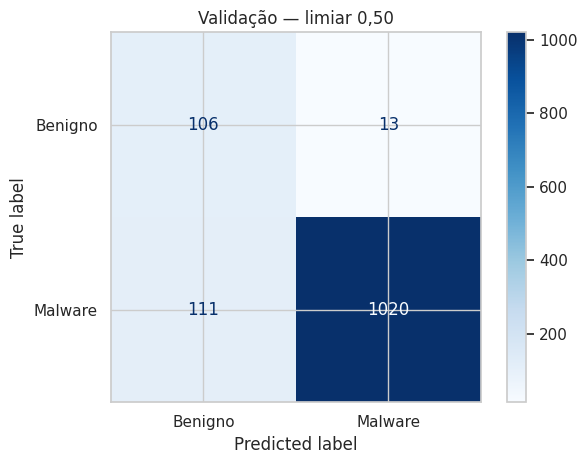

In [10]:
ConfusionMatrixDisplay.from_predictions(
    y_valid, pred_valid_05,
    display_labels=['Benigno', 'Malware'], cmap='Blues'
)
plt.title('Validação — limiar 0,50')
plt.tight_layout()
plt.show()

## 9. Definir o limiar usando apenas a validação

Primeiro, conservamos a regra do notebook original para obter o limiar de referência: entre os candidatos com recall de malware de pelo menos 95%, escolhemos o de maior precisão; em caso de empate, o maior limiar. Esse critério permanece igual para o modelo original e o modelo com folha mínima 5.

No modelo com folha mínima 5, essa regra produz o limiar de referência **0,33**. A **segunda alteração da AV1** é definir diretamente `LIMIAR = 0.21`, mantendo o modelo treinado. Comparamos os resultados na validação para observar quantos malwares adicionais são detectados e quantos alertas indevidos aparecem.

O recall é medido como resultado dessa mudança. O conjunto de teste não participa da escolha do limiar.


Limiar de referência — folha mínima 5: 0.33
Limiar após a segunda alteração: 0.21


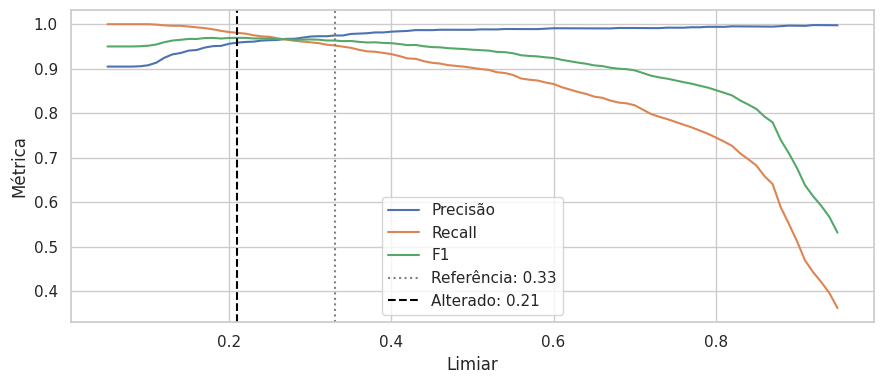

In [11]:
linhas = []
for limiar in np.arange(0.05, 0.96, 0.01):
    pred = (proba_valid >= limiar).astype(int)
    linhas.append({
        'limiar': limiar,
        'precisao': precision_score(y_valid, pred, zero_division=0),
        'recall': recall_score(y_valid, pred),
        'f1': f1_score(y_valid, pred)
    })

tabela_lim = pd.DataFrame(linhas)
# Regra original mantida para o limiar de referência, sem mudar o critério.
candidatos = tabela_lim[tabela_lim['recall'] >= 0.95]
if len(candidatos):
    LIMIAR_FOLHA5 = float(candidatos.sort_values(
        ['precisao', 'limiar'], ascending=[False, False]
    ).iloc[0]['limiar'])
else:
    LIMIAR_FOLHA5 = float(tabela_lim.loc[tabela_lim['f1'].idxmax(), 'limiar'])

# AV1 — segunda alteração: reduzir diretamente o limiar no mesmo modelo.
LIMIAR = 0.21

print('Limiar de referência — folha mínima 5:', round(LIMIAR_FOLHA5, 2))
print('Limiar após a segunda alteração:', LIMIAR)

plt.figure(figsize=(9, 4))
plt.plot(tabela_lim['limiar'], tabela_lim['precisao'], label='Precisão')
plt.plot(tabela_lim['limiar'], tabela_lim['recall'], label='Recall')
plt.plot(tabela_lim['limiar'], tabela_lim['f1'], label='F1')
plt.axvline(LIMIAR_FOLHA5, color='gray', ls=':',
            label=f'Referência: {LIMIAR_FOLHA5:.2f}')
plt.axvline(LIMIAR, color='black', ls='--', label=f'Alterado: {LIMIAR:.2f}')
plt.xlabel('Limiar')
plt.ylabel('Métrica')
plt.legend()
plt.tight_layout()
plt.show()


## AV1 — Comparação do antes e depois na validação

A célula a seguir reconstrói o modelo original com `min_samples_leaf=2` e compara as três versões nos **mesmos exemplos de validação**. O limiar original (**0,46**) e o de referência do modelo com folha 5 (**0,33**) são obtidos pela mesma regra original. A versão final reutiliza o modelo de folha 5 e suas probabilidades, aplicando o limiar definido diretamente como **0,21**.

A função `medir_versao` recebe o limiar e calcula precisão, recall, F1 e a matriz de confusão. A passagem de 0,33 para 0,21 não exige um novo treinamento.

**Legenda:** TP = malware detectado; FN = malware classificado como benigno; FP = benigno classificado como malware; TN = benigno reconhecido corretamente.


In [12]:
def medir_versao(nome, folha, limiar, probabilidades):
    # O limiar é um parâmetro de entrada; as métricas são resultados.
    pred = (probabilidades >= limiar).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_valid, pred, labels=[0, 1]).ravel()
    return {
        "Versão": nome,
        "min_samples_leaf": folha,
        "Limiar": float(limiar),
        "Precisão": precision_score(y_valid, pred, zero_division=0),
        "Recall": recall_score(y_valid, pred),
        "F1": f1_score(y_valid, pred),
        "TP": int(tp), "FP": int(fp),
        "FN": int(fn), "TN": int(tn)
    }

# Reproduz o modelo original com os mesmos dados de treino.
modelo_original = RandomForestClassifier(
    n_estimators=250,
    min_samples_leaf=2,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_SEED
)
modelo_original.fit(X_treino, y_treino)
proba_original = modelo_original.predict_proba(X_valid)[:, 1]

# Aplica ao original a mesma regra de referência usada na seção 9.
linhas_original = []
for t in np.arange(0.05, 0.96, 0.01):
    pred = (proba_original >= t).astype(int)
    linhas_original.append({
        'limiar': t,
        'precisao': precision_score(y_valid, pred, zero_division=0),
        'recall': recall_score(y_valid, pred),
        'f1': f1_score(y_valid, pred)
    })
tabela_original = pd.DataFrame(linhas_original)
candidatos_original = tabela_original[tabela_original['recall'] >= 0.95]
if len(candidatos_original):
    LIMIAR_ORIGINAL = float(candidatos_original.sort_values(
        ['precisao', 'limiar'], ascending=[False, False]
    ).iloc[0]['limiar'])
else:
    LIMIAR_ORIGINAL = float(tabela_original.loc[
        tabela_original['f1'].idxmax(), 'limiar'
    ])

# As duas últimas linhas usam exatamente o mesmo modelo e probabilidades.
comparacao = pd.DataFrame([
    medir_versao("Original", 2, LIMIAR_ORIGINAL, proba_original),
    medir_versao("Folha mínima 5", 5, LIMIAR_FOLHA5, proba_valid),
    medir_versao("Folha 5 + limiar 0,21", 5, LIMIAR, proba_valid)
])
display(comparacao.round(3))


,Versão,min_samples_leaf,Limiar,Precisão,Recall,F1,TP,FP,FN,TN
0,Original,2,0.46,0.982,0.955,0.968,1080,20,51,99
1,Folha mínima 5,5,0.33,0.975,0.952,0.963,1077,28,54,91
2,"Folha 5 + limiar 0,21",5,0.21,0.959,0.981,0.969,1109,48,22,71


### Resultados observados e justificativa

- **Alteração 1 — folha mínima de 2 para 5:** após recalibrar o limiar pela mesma regra original, ele passou de **0,46 para 0,33**. O recall de malware caiu de **95,5% para 95,2%**; os falsos negativos passaram de **51 para 54** e os falsos positivos de **20 para 28**. A configuração com folha 5 e limiar recalibrado teve resultados piores nessa validação. Como modelo e limiar mudaram, essa diferença não pode ser atribuída exclusivamente ao tamanho da folha.
- **Alteração 2 — limiar de 0,33 para 0,21:** mantendo o mesmo modelo com folha mínima 5 e as mesmas probabilidades, reduzimos diretamente o limiar. O recall calculado subiu de **95,2% para 98,1%**, e os falsos negativos caíram de **54 para 22**: foram **32 malwares adicionais detectados**. Os falsos positivos aumentaram de **28 para 48**, e a precisão caiu de **97,5% para 95,9%**.
- **Original versus versão final:** foram detectados **29 malwares adicionais** na validação, com **28 alarmes falsos adicionais**. O F1 passou de **0,968 para 0,969**. Essa comparação resume o efeito conjunto da configuração do modelo e do limiar final.

Em cibersegurança, um FN representa uma ameaça tratada como benigna; um FP representa um programa legítimo sinalizado como malware. A redução do limiar aumentou a detecção de malware, com o custo de mais alertas indevidos e mais trabalho de análise. Precisão, recall e F1 registram os efeitos dessas decisões; não são parâmetros alterados diretamente.


## 10. Avaliação final — agora podemos abrir o teste

Depois desta célula, não altere o modelo ou o limiar com base no resultado do teste. Se alterarmos, o teste deixa de ser independente.

Limiar: 0.21
              precision    recall  f1-score   support

     Benigno       0.80      0.55      0.66       119
     Malware       0.95      0.99      0.97      1131

    accuracy                           0.94      1250
   macro avg       0.88      0.77      0.81      1250
weighted avg       0.94      0.94      0.94      1250

ROC-AUC: 0.968
PR-AUC : 0.996


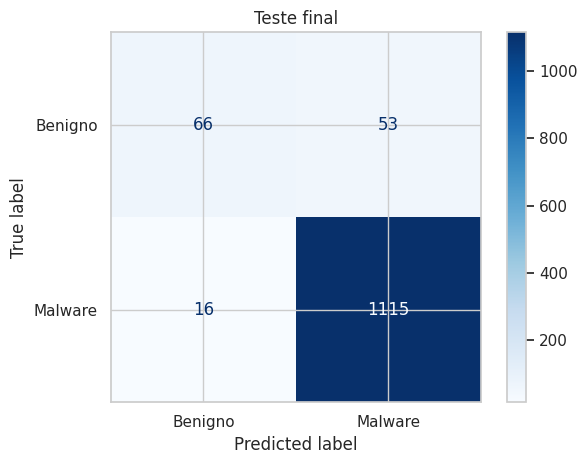

In [13]:
proba_teste = modelo.predict_proba(X_teste)[:, 1]
pred_teste = (proba_teste >= LIMIAR).astype(int)

print('Limiar:', round(float(LIMIAR), 2))
print(classification_report(y_teste, pred_teste, target_names=['Benigno', 'Malware']))
print('ROC-AUC:', f'{roc_auc_score(y_teste, proba_teste):.3f}')
print('PR-AUC :', f'{average_precision_score(y_teste, proba_teste):.3f}')

ConfusionMatrixDisplay.from_predictions(
    y_teste, pred_teste,
    display_labels=['Benigno', 'Malware'], cmap='Blues'
)
plt.title('Teste final')
plt.tight_layout()
plt.show()

### Interpretação do teste final

Depois de definidas as duas alterações na validação, a versão final — **folha mínima 5 e limiar 0,21** — foi aplicada ao conjunto de teste. A matriz de confusão apresentou **1.115 TP**, **16 FN**, **53 FP** e **66 TN**. Isso corresponde a recall de malware de aproximadamente **98,6%** e precisão de aproximadamente **95,5%**. O ROC-AUC foi **0,968** e o PR-AUC, **0,996**.

O resultado deve ser interpretado com cautela: **53 dos 119 arquivos benignos do teste** foram sinalizados como malware. Além disso, como discutido na seção de limitações, benignos e malwares foram coletados de fontes diferentes. O modelo pode aprender características da origem dos dados; portanto, os números não garantem o mesmo desempenho em outro ambiente.

**Conclusão:** a configuração com folha mínima 5 e limiar recalibrado não melhorou os resultados da validação. Mantendo esse modelo, a redução do limiar de 0,33 para 0,21 diminuiu os malwares não detectados e aumentou os alarmes falsos. A escolha do limiar depende da capacidade de investigar alertas e do custo de cada tipo de erro.


## 11. Quais features o modelo utilizou?

A importância do Random Forest indica quanto uma feature ajudou as árvores a reduzir impureza.

> **Importância não é causalidade.** Uma feature importante pode representar viés de coleta ou uma regularidade fácil de evadir.

In [ ]:
importancias = pd.Series(modelo.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
importancias.head(15).sort_values().plot(kind='barh', color='#0E7C7B')
plt.title('15 features mais utilizadas pelo modelo')
plt.xlabel('importância no Random Forest')
plt.tight_layout()
plt.show()

importancias.head(15).to_frame('importancia')

### Perguntas para discussão

- As features do topo fazem sentido para malware?
- Alguma pode denunciar o ambiente ou a fonte de coleta?
- O que aconteceria se o atacante alterasse apenas essa feature?
- Duas features parecidas podem dividir importância entre si?

## 12. Ablação por famílias de features

Vamos comparar grupos de features usando validação cruzada somente no conjunto de treino + validação. O objetivo é avaliar quanto cada família contribui.

In [ ]:
grupos = {
    'Estrutura': features_estrutura,
    'Entropia/seções': features_entropia,
    'Imports/capacidades': features_imports,
    'Todas': features
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
resultados = []

for nome, cols in grupos.items():
    m = RandomForestClassifier(
        n_estimators=150, min_samples_leaf=2,
        class_weight='balanced', n_jobs=-1,
        random_state=RANDOM_SEED
    )
    scores = cross_validate(
        m, X_treino_val[cols], y_treino_val,
        cv=cv, scoring={'recall': 'recall', 'f1': 'f1', 'pr_auc': 'average_precision'},
        n_jobs=-1
    )
    resultados.append({
        'grupo': nome,
        'recall_medio': scores['test_recall'].mean(),
        'f1_medio': scores['test_f1'].mean(),
        'pr_auc_media': scores['test_pr_auc'].mean()
    })

pd.DataFrame(resultados).set_index('grupo').round(3)

## 13. Limitações que precisam acompanhar o resultado

1. **Viés de origem:** benignos e maliciosos foram coletados de fontes diferentes.
2. **Idade:** parte dos dados representa software e malware antigos.
3. **Split aleatório:** variantes próximas podem aparecer em treino e teste.
4. **Rótulo:** “malware” depende do processo de rotulagem usado pelos autores.
5. **Evasão:** um atacante pode alterar features estáticas sem mudar o comportamento.

Para um projeto mais robusto, use uma base temporal como BODMAS ou EMBER e faça divisão por tempo, família e campanha.

## 14. Exportar features para o Splunk (opcional)

Vamos produzir um CSV pequeno, sem hashes ou executáveis. Os nomes das colunas abaixo serão usados nos comandos SPL.

In [ ]:
splunk_df = pd.DataFrame({
    'sample_id': df['sample_id'],
    'label': df['label'].map({0: 'benign', 1: 'malicious'}),
    'file_size': pd.to_numeric(df['filesize'], errors='coerce').fillna(0),
    'entropy': df[cols_entropia].apply(pd.to_numeric, errors='coerce').fillna(0).mean(axis=1),
    'num_sections': pd.to_numeric(df['number_of_sections'], errors='coerce').fillna(0),
    'num_imports': pd.to_numeric(df['number_of_import_symbols'], errors='coerce').fillna(0),
    'size_code': pd.to_numeric(df['size_code'], errors='coerce').fillna(0),
    'entry_point': pd.to_numeric(df['AddressOfEntryPoint'], errors='coerce').fillna(0),
    'has_virtual_alloc': (pd.to_numeric(df['VirtualAlloc'], errors='coerce').fillna(0) > 0).astype(int),
    'has_write_process_memory': (pd.to_numeric(df['WriteProcessMemory'], errors='coerce').fillna(0) > 0).astype(int)
})

CAMINHO_SPLUNK = '/content/malware_features.csv'
splunk_df.to_csv(CAMINHO_SPLUNK, index=False)
print('Arquivo salvo em:', CAMINHO_SPLUNK)
print('Dimensões:', splunk_df.shape)
splunk_df.head()

In [ ]:
# Baixar o CSV no navegador do Colab
try:
    from google.colab import files
    files.download(CAMINHO_SPLUNK)
except ImportError:
    print('Fora do Colab: arquivo disponível em', CAMINHO_SPLUNK)

## 15. SPL correspondente no Splunk AI Toolkit (opcional)

Depois de enviar o arquivo como lookup:

### Treinar e salvar

```spl
| inputlookup malware_features.csv
| sample partitions=100 seed=42
| search partition_number<=70
| fit RandomForestClassifier label from file_size entropy num_sections num_imports size_code entry_point has_virtual_alloc has_write_process_memory into malware_rf_v1
```

### Aplicar no teste

```spl
| inputlookup malware_features.csv
| sample partitions=100 seed=42
| search partition_number>70
| apply malware_rf_v1 as predicao
| `confusionmatrix(label, predicao)`
```

> O split com `sample` é adequado para a demonstração. Em produção, carregue uma coluna de tempo/campanha e preserve o futuro como teste.

## Entregável da aula

- [ ] Base real carregada e origem dos dados documentada.
- [ ] Conjunto de features justificado por famílias.
- [ ] Treino, validação e teste separados antes da modelagem.
- [ ] Baseline e Random Forest comparados.
- [ ] Limiar escolhido somente na validação.
- [ ] Teste final executado uma única vez.
- [ ] Importâncias e riscos de leakage discutidos.
- [ ] Respostas das perguntas registradas no notebook.